# Principal Component Analysis with Cancer Data

In [7]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [8]:
c_df = pd.read_csv("breast-cancer-wisconsin-data.csv") #("d:\\ml_data\\car-mpg.csv") 
c_df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [0]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [9]:
print('c_df datatypes', c_df.dtypes)
print('c_df Shape',c_df.shape)

c_df datatypes ID                              int64
ClumpThickness                  int64
Cell Size                       int64
Cell Shape                      int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Normal Nucleoli                 int64
Bland Chromatin                 int64
Mitoses                         int64
Class                           int64
dtype: object
c_df Shape (699, 11)


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [10]:
# We could see "?" values in column, this should be removed from data set

#c_df.loc[c_df[] == '?']
c_df = c_df.replace('?', np.nan)

# Check for missing value in any other column
c_df.info()

#temp= pd.DataFrame(c_df.isnull()) 
#temp=temp[temp['Bare Nuclei'] == True]
#temp=temp[temp == True]
#temp.head()
#c_df = c_df.replace('?', np.nan)
#print(c_df.info())
#c_df = c_df.apply(lambda x: x.fillna(x.median()),axis=0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    683 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [11]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
#temp = pd.DataFrame(mpg_df.Bare Nuclei.str.isnull())
temp=c_df['Bare Nuclei'] =='?'
temp=temp[temp == False]
temp.head()

# Count number of rows in a dataframe that contains NaN any column
seriesObj = c_df.apply(lambda x: x.isnull().any(), axis=1)
numOfRows = len(seriesObj[seriesObj == True].index)
 
print('Number of Rows in dataframe which contain NaN in any column : ', numOfRows)

Number of Rows in dataframe which contain NaN in any column :  16


In [12]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values
c_df = c_df.apply(lambda x: x.fillna(x.median()),axis=0)
seriesObj = c_df.apply(lambda x: x.isnull().any(), axis=1)
numOfRows = len(seriesObj[seriesObj == True].index)
 
print('Number of Rows in dataframe which contain NaN in any column : ', numOfRows)

# converting the hp column from object / string type to float
c_df['Bare Nuclei'] = c_df['Bare Nuclei'].astype('float64')  

Number of Rows in dataframe which contain NaN in any column :  0


# Q4. Perform bi variate analysis including correlation & pairplots. 


In [13]:
# Check for correlation of variable
c_df.corr()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ID,1.000000,-0.055308,-0.041603,-0.041576,-0.064878,-0.045528,-0.092533,-0.060051,-0.052072,-0.034901,-0.080226
ClumpThickness,-0.055308,1.000000,0.644913,0.654589,0.486356,0.521816,0.590008,0.558428,0.535835,0.350034,0.716001
Cell Size,-0.041603,0.644913,1.000000,0.906882,0.705582,0.751799,0.686673,0.755721,0.722865,0.458693,0.817904
Cell Shape,-0.041576,0.654589,0.906882,1.000000,0.683079,0.719668,0.707474,0.735948,0.719446,0.438911,0.818934
Marginal Adhesion,-0.064878,0.486356,0.705582,0.683079,1.000000,0.599599,0.666971,0.666715,0.603352,0.417633,0.696800
Single Epithelial Cell Size,-0.045528,0.521816,0.751799,0.719668,0.599599,1.000000,0.583701,0.616102,0.628881,0.479101,0.682785
Bare Nuclei,-0.092533,0.590008,0.686673,0.707474,0.666971,0.583701,1.000000,0.674215,0.574778,0.342397,0.818968
Normal Nucleoli,-0.060051,0.558428,0.755721,0.735948,0.666715,0.616102,0.674215,1.000000,0.665878,0.344169,0.756616
Bland Chromatin,-0.052072,0.535835,0.722865,0.719446,0.603352,0.628881,0.574778,0.665878,1.000000,0.428336,0.712244
Mitoses,-0.034901,0.350034,0.458693,0.438911,0.417633,0.479101,0.342397,0.344169,0.428336,1.000000,0.423170


In [0]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


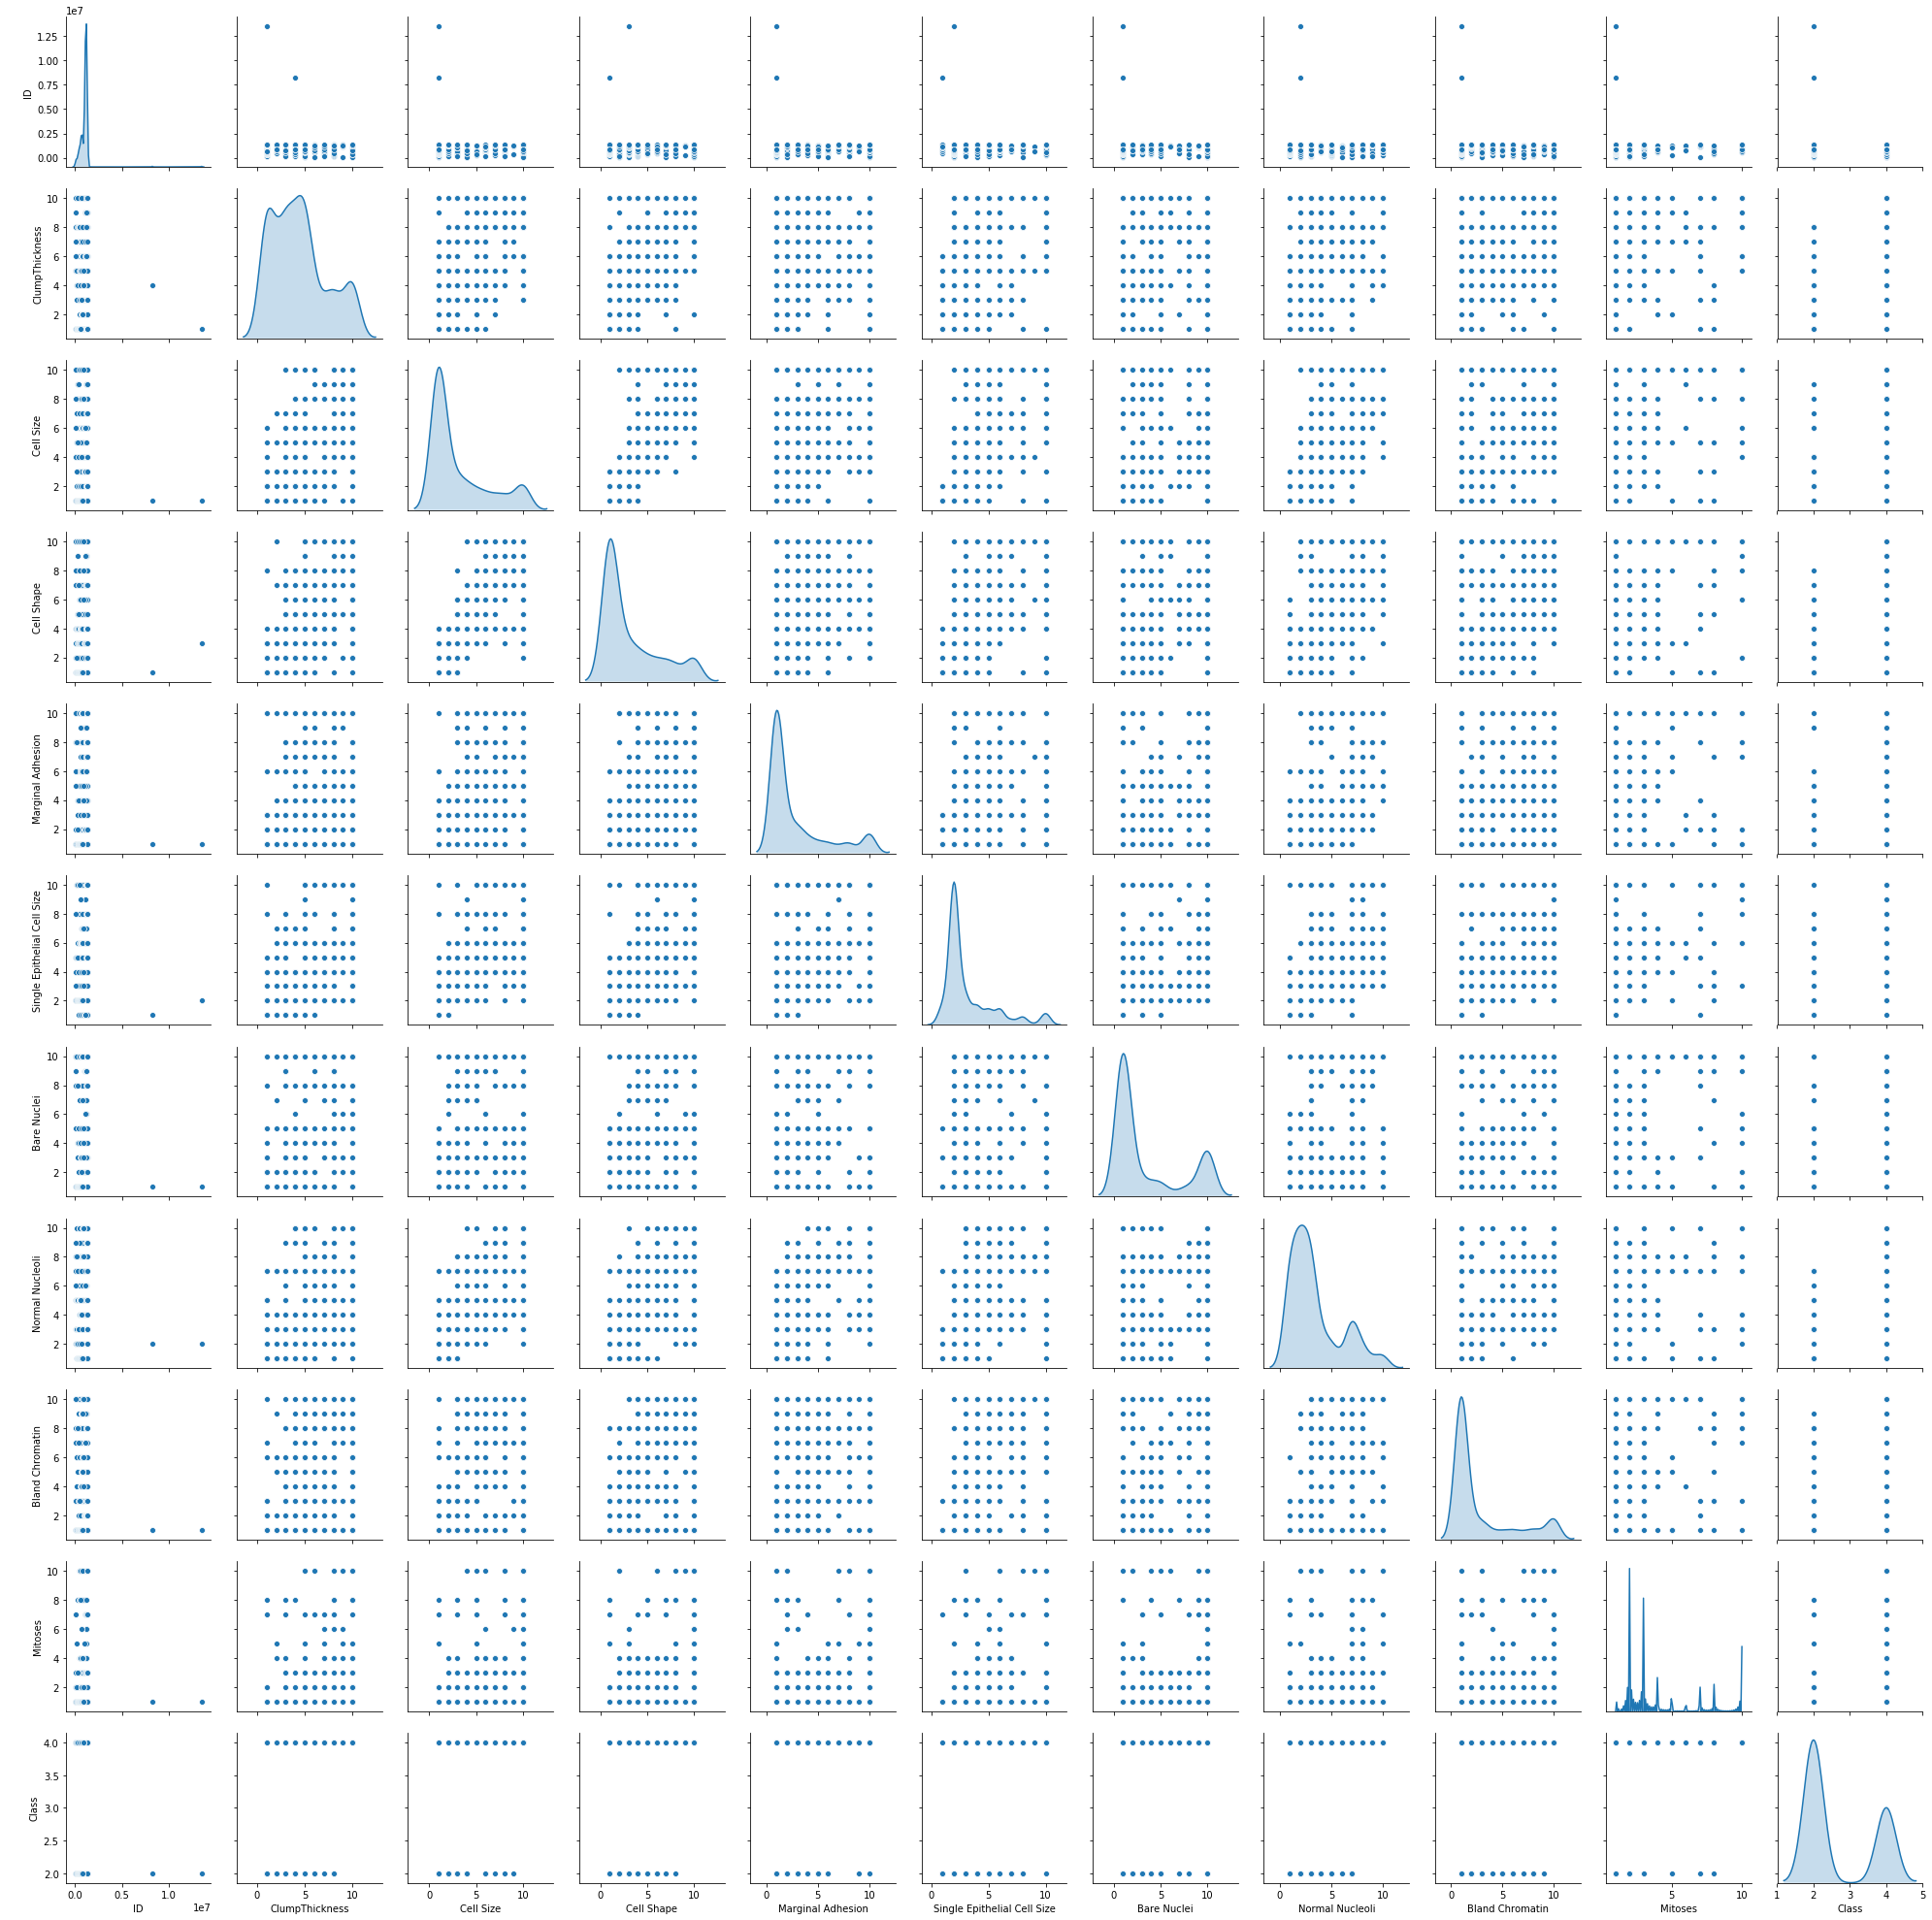

In [14]:
#Let us check for pair plots
sns.pairplot(c_df, diag_kind='kde') 

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [0]:
# We could see most of the outliers are now removed.

In [15]:
c_df1 = c_df.drop("ID", axis=1)
c_df1.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


In [17]:
X = c_df1.drop('Class',axis=1)
y = c_df1['Class']

In [ ]:
# data.drop(["scaled_variance.1"], axis=1).boxplot(by = 'Class',  layout=(4,3), figsize=(15, 10))

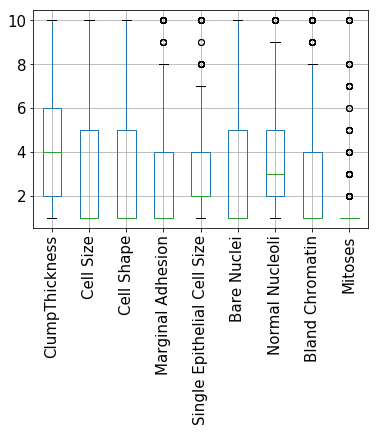

In [18]:
c_df.boxplot(column=['ClumpThickness','Cell Size','Cell Shape','Marginal Adhesion','Single Epithelial Cell Size',
                      'Bare Nuclei','Normal Nucleoli','Bland Chromatin','Mitoses'], rot=90, fontsize=15)

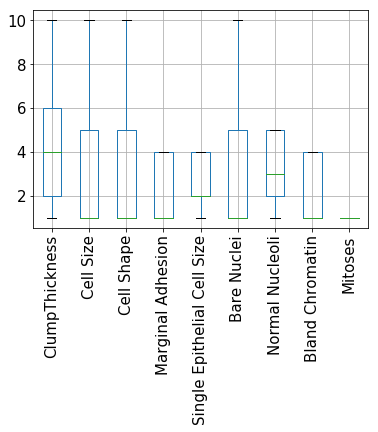

In [19]:
pd.crosstab(c_df['Marginal Adhesion'], c_df['Class'])

c_df['Marginal Adhesion']=np.where(c_df['Marginal Adhesion']>4,4,c_df['Marginal Adhesion'])
c_df['Single Epithelial Cell Size']=np.where(c_df['Single Epithelial Cell Size']>4,4,c_df['Single Epithelial Cell Size'])
c_df['Normal Nucleoli']=np.where(c_df['Normal Nucleoli']>5,5,c_df['Normal Nucleoli'])
c_df['Bland Chromatin']=np.where(c_df['Bland Chromatin']>4,4,c_df['Bland Chromatin'])
c_df['Mitoses']=np.where(c_df['Mitoses']>1,1,c_df['Mitoses'])

c_df.boxplot(column=['ClumpThickness','Cell Size','Cell Shape','Marginal Adhesion','Single Epithelial Cell Size',
                      'Bare Nuclei','Normal Nucleoli','Bland Chromatin','Mitoses'], rot=90, fontsize=15)

# Q6 Create a covariance matrix for identifying Principal components

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

In [21]:
# PCA
# Step 1 - Create covariance matrix
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00143266 0.64583645 0.65552689 0.48705303 0.52256381 0.5908535
  0.5592282  0.53660222 0.35053534]
 [0.64583645 1.00143266 0.90818117 0.70659267 0.75287621 0.68765657
  0.75680368 0.72390044 0.4593503 ]
 [0.65552689 0.90818117 1.00143266 0.68405782 0.72069948 0.70848734
  0.73700282 0.72047704 0.43953974]
 [0.48705303 0.70659267 0.68405782 1.00143266 0.60045809 0.66792658
  0.66767051 0.60421681 0.41823111]
 [0.52256381 0.75287621 0.72069948 0.60045809 1.00143266 0.5845377
  0.61698451 0.62978166 0.47978787]
 [0.5908535  0.68765657 0.70848734 0.66792658 0.5845377  1.00143266
  0.67518063 0.5756016  0.34288766]
 [0.5592282  0.75680368 0.73700282 0.66767051 0.61698451 0.67518063
  1.00143266 0.66683179 0.34466258]
 [0.53660222 0.72390044 0.72047704 0.60421681 0.62978166 0.5756016
  0.66683179 1.00143266 0.42894941]
 [0.35053534 0.4593503  0.43953974 0.41823111 0.47978787 0.34288766
  0.34466258 0.42894941 1.00143266]]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q7 Identify eigen values and eigen vector

In [0]:
# Step 2- Get eigen values and eigen vector

In [22]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.30280515  0.14602888 -0.86221719  0.0014072  -0.08821658  0.07192848
   0.24081701  0.26946934 -0.00131277]
 [-0.38119012  0.04956364  0.01909154  0.73568065  0.2026394  -0.13735749
  -0.44088652  0.1000979   0.21521315]
 [-0.37757351  0.08526953 -0.0345843  -0.66537497  0.17515522 -0.10469081
  -0.58600968  0.03200191  0.14204379]
 [-0.33282286  0.04471887  0.42144828 -0.04671812 -0.4703171   0.03462797
   0.11866965  0.68083355 -0.0861038 ]
 [-0.33639134 -0.16403795  0.11010437 -0.06786939  0.37332927 -0.68258246
   0.45057208 -0.03559797 -0.18337725]
 [-0.33349748  0.2477099  -0.00367104  0.07339423 -0.5431767  -0.1275059
  -0.10299896 -0.57486596 -0.41187463]
 [-0.3459564   0.22994199  0.19744944 -0.05881119 -0.00698988  0.25519148
   0.40975993 -0.31459721  0.67301535]
 [-0.33584019 -0.02502678  0.13164974  0.01889835  0.45537199  0.63180293
   0.08247514 -0.03841564 -0.50406321]
 [-0.22981766 -0.90839421 -0.09459348 -0.0075291  -0.23968608  0.1316273
  -0.0

# Q8 Find variance and cumulative variance by each eigen vector

In [23]:
# Step 3 (continued): Sort eigenvalues in descending order

# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(eigenvalues[index], eigenvectors[:,index]) for index in range(len(eigenvalues))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(eigenvalues))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(eigenvalues))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

[(5.898551899582241, array([-0.30280515, -0.38119012, -0.37757351, -0.33282286, -0.33639134,
       -0.33349748, -0.3459564 , -0.33584019, -0.22981766])), (0.7758830680807647, array([ 0.14602888,  0.04956364,  0.08526953,  0.04471887, -0.16403795,
        0.2477099 ,  0.22994199, -0.02502678, -0.90839421])), (0.539601554819918, array([-0.86221719,  0.01909154, -0.0345843 ,  0.42144828,  0.11010437,
       -0.00367104,  0.19744944,  0.13164974, -0.09459348])), (0.4664055506212335, array([-0.08821658,  0.2026394 ,  0.17515522, -0.4703171 ,  0.37332927,
       -0.5431767 , -0.00698988,  0.45537199, -0.23968608])), (0.38101775525038944, array([ 0.07192848, -0.13735749, -0.10469081,  0.03462797, -0.68258246,
       -0.1275059 ,  0.25519148,  0.63180293,  0.1316273 ])), (0.30405591873920346, array([ 0.26946934,  0.1000979 ,  0.03200191,  0.68083355, -0.03559797,
       -0.57486596, -0.31459721, -0.03841564, -0.14360708])), (0.29609473619399845, array([-0.00131277,  0.21521315,  0.14204379, -

In [24]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100%


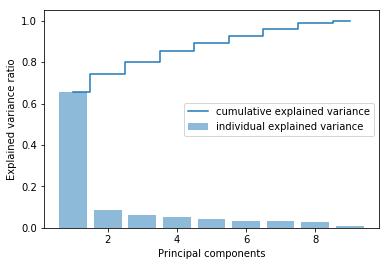

In [25]:
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=7)
pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=7, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [27]:
X_pca = pca.transform(X_std)
X_pca.shape

(699, 7)

In [30]:
pca.components_

array([[ 0.30280515,  0.38119012,  0.37757351,  0.33282286,  0.33639134,
         0.33349748,  0.3459564 ,  0.33584019,  0.22981766],
       [-0.14602888, -0.04956364, -0.08526953, -0.04471887,  0.16403795,
        -0.2477099 , -0.22994199,  0.02502678,  0.90839421],
       [-0.86221719,  0.01909154, -0.0345843 ,  0.42144828,  0.11010437,
        -0.00367104,  0.19744944,  0.13164974, -0.09459348],
       [-0.08821658,  0.2026394 ,  0.17515522, -0.4703171 ,  0.37332927,
        -0.5431767 , -0.00698988,  0.45537199, -0.23968608],
       [-0.07192848,  0.13735749,  0.10469081, -0.03462797,  0.68258246,
         0.1275059 , -0.25519148, -0.63180293, -0.1316273 ],
       [ 0.26946934,  0.1000979 ,  0.03200191,  0.68083355, -0.03559797,
        -0.57486596, -0.31459721, -0.03841564, -0.14360708],
       [-0.00131277,  0.21521315,  0.14204379, -0.0861038 , -0.18337725,
        -0.41187463,  0.67301535, -0.50406321,  0.12567403]])

In [31]:
pca.explained_variance_

array([5.8985519 , 0.77588307, 0.53960155, 0.46640555, 0.38101776,
       0.30405592, 0.29609474])

In [33]:
pca.explained_variance_ratio_

array([0.65445704, 0.0860859 , 0.05986995, 0.0517487 , 0.04227474,
       0.03373566, 0.03285235])

# Q10 Find correlation between components and features

In [36]:
pca_df=pd.DataFrame(X_pca)
pca_df.head(10)

,0,1,2,3,4,5,6
0,-1.456220,-0.110210,-0.574438,-0.019405,-0.151968,0.074669,0.326013
1,1.466279,-0.544894,0.283038,-0.660281,1.692802,-0.362600,-1.043214
2,-1.579311,-0.074854,0.037413,-0.106777,-0.065612,-0.275702,0.213148
3,1.505247,-0.558853,-0.612984,1.441160,-0.443578,-0.092462,-0.260995
4,-1.330551,-0.089657,0.027402,-0.317714,-0.150677,0.456119,0.266126
5,5.054140,-1.542614,0.476466,0.232720,0.397850,0.064534,0.406616
6,-1.057400,-0.518582,0.642164,-1.244683,0.267347,-1.737896,-0.696306
7,-1.651934,0.016774,0.333214,0.133631,-0.040026,-0.201864,0.375242
8,-1.526659,2.354349,-0.037983,-0.479020,-0.173023,-0.289584,0.068309
9,-1.580810,0.019803,-0.342779,0.081271,0.023373,0.140838,0.120849


In [37]:
pca_df.corr()

,0,1,2,3,4,5,6
0,1.000000e+00,3.260716e-15,8.801378e-16,6.820120e-16,8.700082e-17,1.659212e-16,9.310719e-16
1,3.260716e-15,1.000000e+00,-1.027534e-16,9.122081e-17,1.491950e-17,-1.742174e-16,1.367220e-16
2,8.801378e-16,-1.027534e-16,1.000000e+00,2.062451e-16,9.041579e-17,-3.614642e-16,3.979265e-17
3,6.820120e-16,9.122081e-17,2.062451e-16,1.000000e+00,-5.868613e-16,-6.665047e-16,-3.680917e-17
4,8.700082e-17,1.491950e-17,9.041579e-17,-5.868613e-16,1.000000e+00,-1.795056e-16,6.250875e-17
5,1.659212e-16,-1.742174e-16,-3.614642e-16,-6.665047e-16,-1.795056e-16,1.000000e+00,2.920884e-16
6,9.310719e-16,1.367220e-16,3.979265e-17,-3.680917e-17,6.250875e-17,2.920884e-16,1.000000e+00


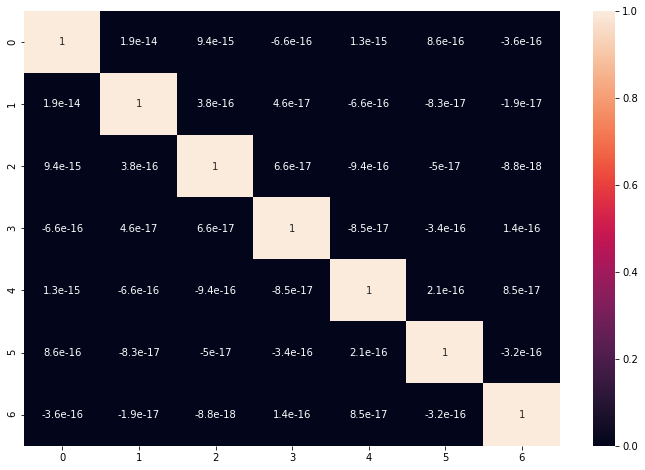

In [60]:
plt.figure(figsize=(12,8))
pcadata_corr=pca_df.corr()
sns.heatmap(pcadata_corr,
           xticklabels=pcadata_corr.columns.values,
           yticklabels=pcadata_corr.columns.values, 
           annot=True);

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


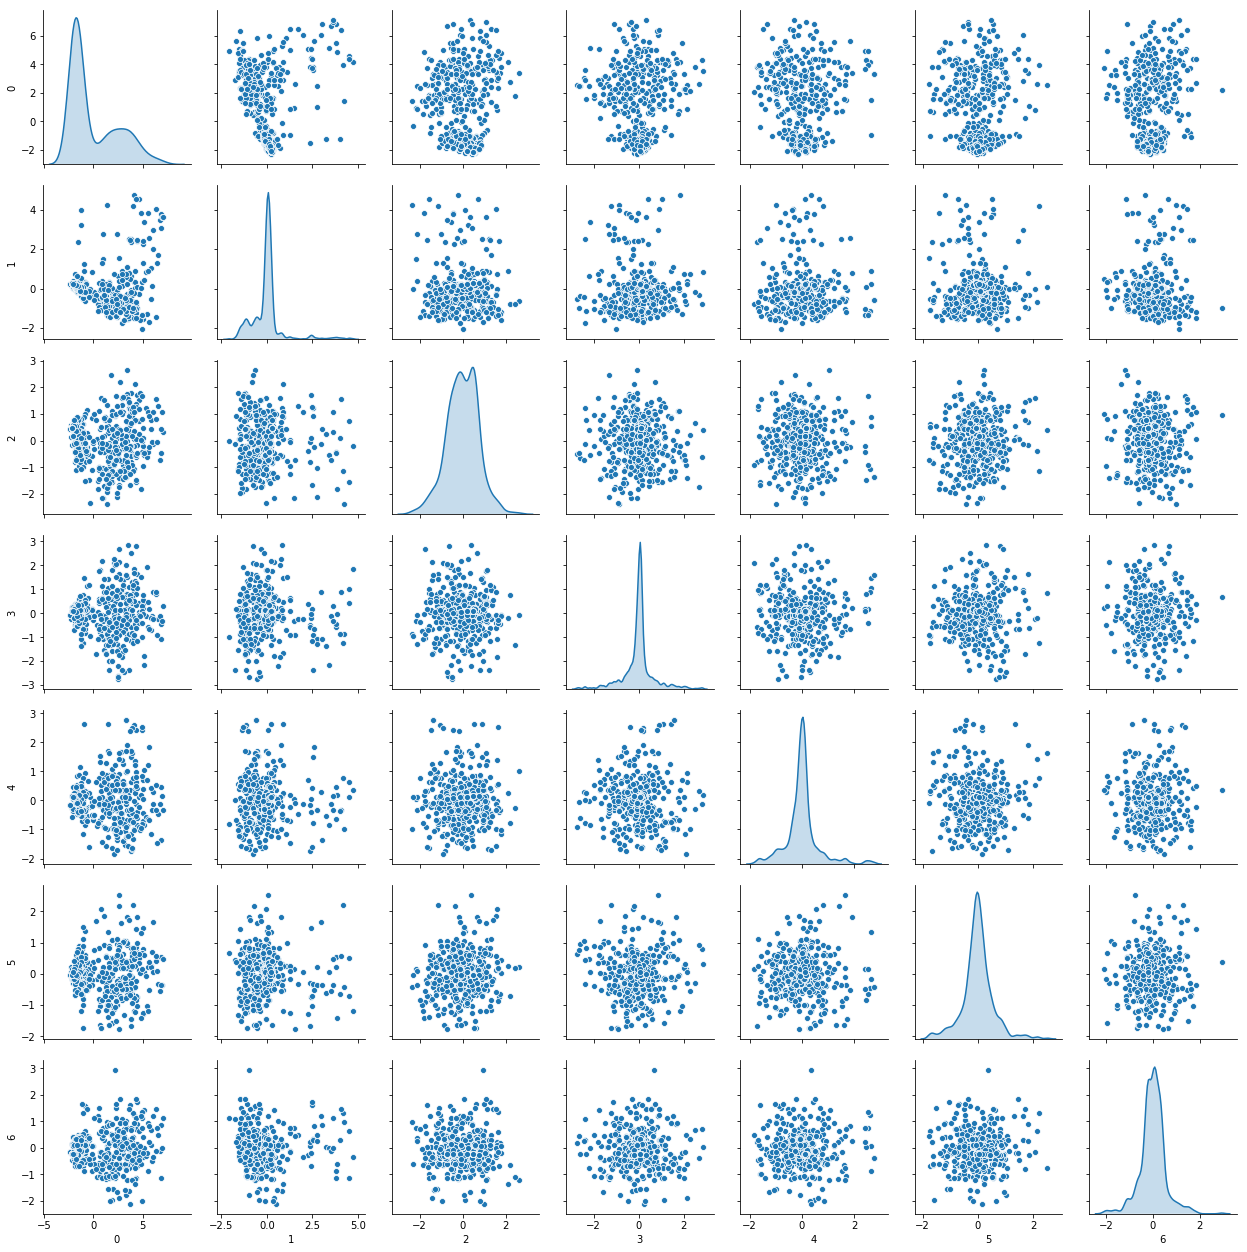

In [38]:
sns.pairplot(pca_df, diag_kind='kde') 